In [1]:
import pandas as pd
import numpy as np

In [2]:
data= pd.read_csv("Performance.csv")

In [4]:
data

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,U0996,23,Female,Working Professional,Simulation,4.0,28.0,Morning,7.8,8,4,95,96,Neutral
996,U0997,30,Female,Student,Puzzle,2.9,20.3,Morning,4.9,4,7,62,67,Neutral
997,U0998,18,Male,Working Professional,Action,1.0,7.0,Night,4.6,2,8,92,89,Neutral
998,U0999,25,Female,Student,Simulation,4.5,31.5,Morning,8.4,7,4,70,75,Neutral


In [5]:
data.describe()

,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,26.600000,3.320300,23.242100,6.479500,5.454000,6.065000,75.07800,75.275000
std,5.207218,1.613059,11.291414,1.155848,2.281905,2.010178,11.67494,12.058805
min,18.000000,0.500000,3.500000,4.500000,2.000000,3.000000,55.00000,50.000000
25%,22.000000,2.000000,14.000000,5.475000,3.000000,4.000000,65.00000,65.000000
50%,27.000000,3.300000,23.100000,6.500000,5.000000,6.000000,75.00000,75.000000
75%,31.000000,4.800000,33.600000,7.500000,7.000000,8.000000,85.00000,86.000000
max,35.000000,6.000000,42.000000,8.500000,9.000000,9.000000,95.00000,100.000000


In [7]:
col= data.columns.tolist()

In [9]:
for col_1 in col:
    print(data[col_1].dtype)

object
int64
object
object
object
float64
float64
object
float64
int64
int64
int64
int64
object


In [12]:
for i in range(1, len(col)):
    if data[col[i]].dtype=="object":
        print(set(data[col[i]]))

{'Male', 'Female'}
{'Working Professional', 'Student'}
{'Simulation', 'Action', 'Casual', 'Strategy', 'Sports', 'Puzzle'}
{'Evening', 'Night', 'Morning'}
{'Neutral', 'Positive', 'Negative'}


In [13]:
for i in range(1, len(col)):
    if data[col[i]].dtype=="object":
        print(data[col[i]].value_counts())

Gender
Female    513
Male      487
Name: count, dtype: int64
Occupation
Student                 524
Working Professional    476
Name: count, dtype: int64
Game_Type
Simulation    192
Action        180
Sports        161
Casual        160
Strategy      157
Puzzle        150
Name: count, dtype: int64
Primary_Gaming_Time
Morning    341
Evening    338
Night      321
Name: count, dtype: int64
Performance_Impact
Neutral     762
Negative    135
Positive    103
Name: count, dtype: int64


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Daily_Gaming_Hours'}>,
        <Axes: title={'center': 'Weekly_Gaming_Hours'}>],
       [<Axes: title={'center': 'Sleep_Hours'}>,
        <Axes: title={'center': 'Stress_Level'}>,
        <Axes: title={'center': 'Focus_Level'}>],
       [<Axes: title={'center': 'Academic_or_Work_Score'}>,
        <Axes: title={'center': 'Productivity_Level'}>, <Axes: >]],
      dtype=object)

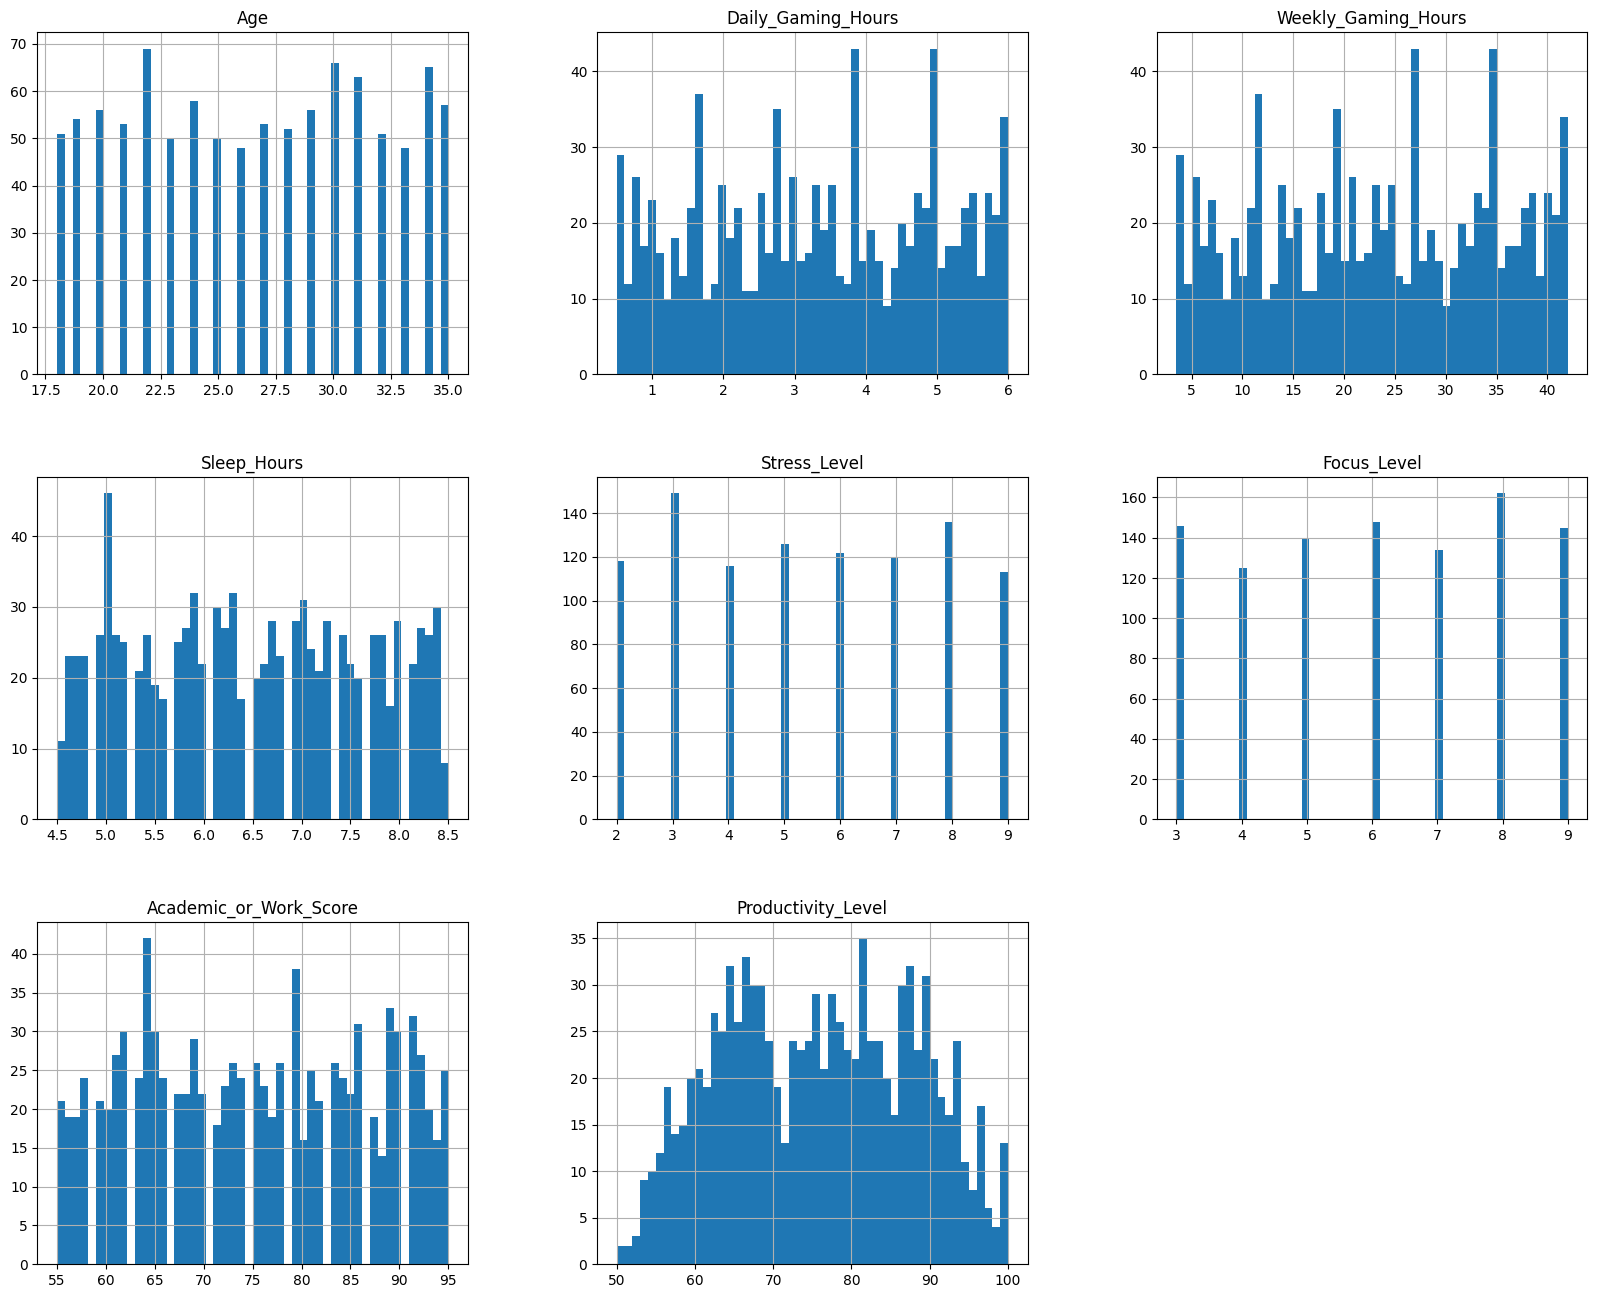

In [14]:
data.hist(bins=50, figsize=(20,16))

In [15]:
for i in range(len(col)):
    if data[col[i]].dtype=="object":
        print(col[i])

User_ID
Gender
Occupation
Game_Type
Primary_Gaming_Time
Performance_Impact


In [16]:
obj_col=[]
for col_1 in col:
    if data[col_1].dtype=="object":
        obj_col.append(col_1)

In [18]:
df= data.drop(["User_ID", "Gender", "Occupation", "Game_Type", "Primary_Gaming_Time", "Performance_Impact"], axis=1)

In [19]:
df.corr()

,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
Age,1.000000,0.060864,0.060864,-0.043857,-0.040976,0.046859,-0.028235,-0.031165
Daily_Gaming_Hours,0.060864,1.000000,1.000000,0.006285,0.032357,0.001198,-0.012049,-0.016374
Weekly_Gaming_Hours,0.060864,1.000000,1.000000,0.006285,0.032357,0.001198,-0.012049,-0.016374
Sleep_Hours,-0.043857,0.006285,0.006285,1.000000,-0.025236,-0.014419,-0.030080,-0.014713
Stress_Level,-0.040976,0.032357,0.032357,-0.025236,1.000000,0.005126,0.013398,0.012883
Focus_Level,0.046859,0.001198,0.001198,-0.014419,0.005126,1.000000,-0.004908,-0.009162
Academic_or_Work_Score,-0.028235,-0.012049,-0.012049,-0.030080,0.013398,-0.004908,1.000000,0.964510
Productivity_Level,-0.031165,-0.016374,-0.016374,-0.014713,0.012883,-0.009162,0.964510,1.000000


In [20]:
from pandas.plotting import scatter_matrix

In [21]:
attributes= df.columns.tolist()

array([[<Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Daily_Gaming_Hours', ylabel='Age'>,
        <Axes: xlabel='Weekly_Gaming_Hours', ylabel='Age'>,
        <Axes: xlabel='Sleep_Hours', ylabel='Age'>,
        <Axes: xlabel='Stress_Level', ylabel='Age'>,
        <Axes: xlabel='Focus_Level', ylabel='Age'>,
        <Axes: xlabel='Academic_or_Work_Score', ylabel='Age'>,
        <Axes: xlabel='Productivity_Level', ylabel='Age'>],
       [<Axes: xlabel='Age', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Daily_Gaming_Hours', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Weekly_Gaming_Hours', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Sleep_Hours', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Stress_Level', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Focus_Level', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Academic_or_Work_Score', ylabel='Daily_Gaming_Hours'>,
        <Axes: xlabel='Productivity_Level', ylabel='Daily_Gaming_Hour

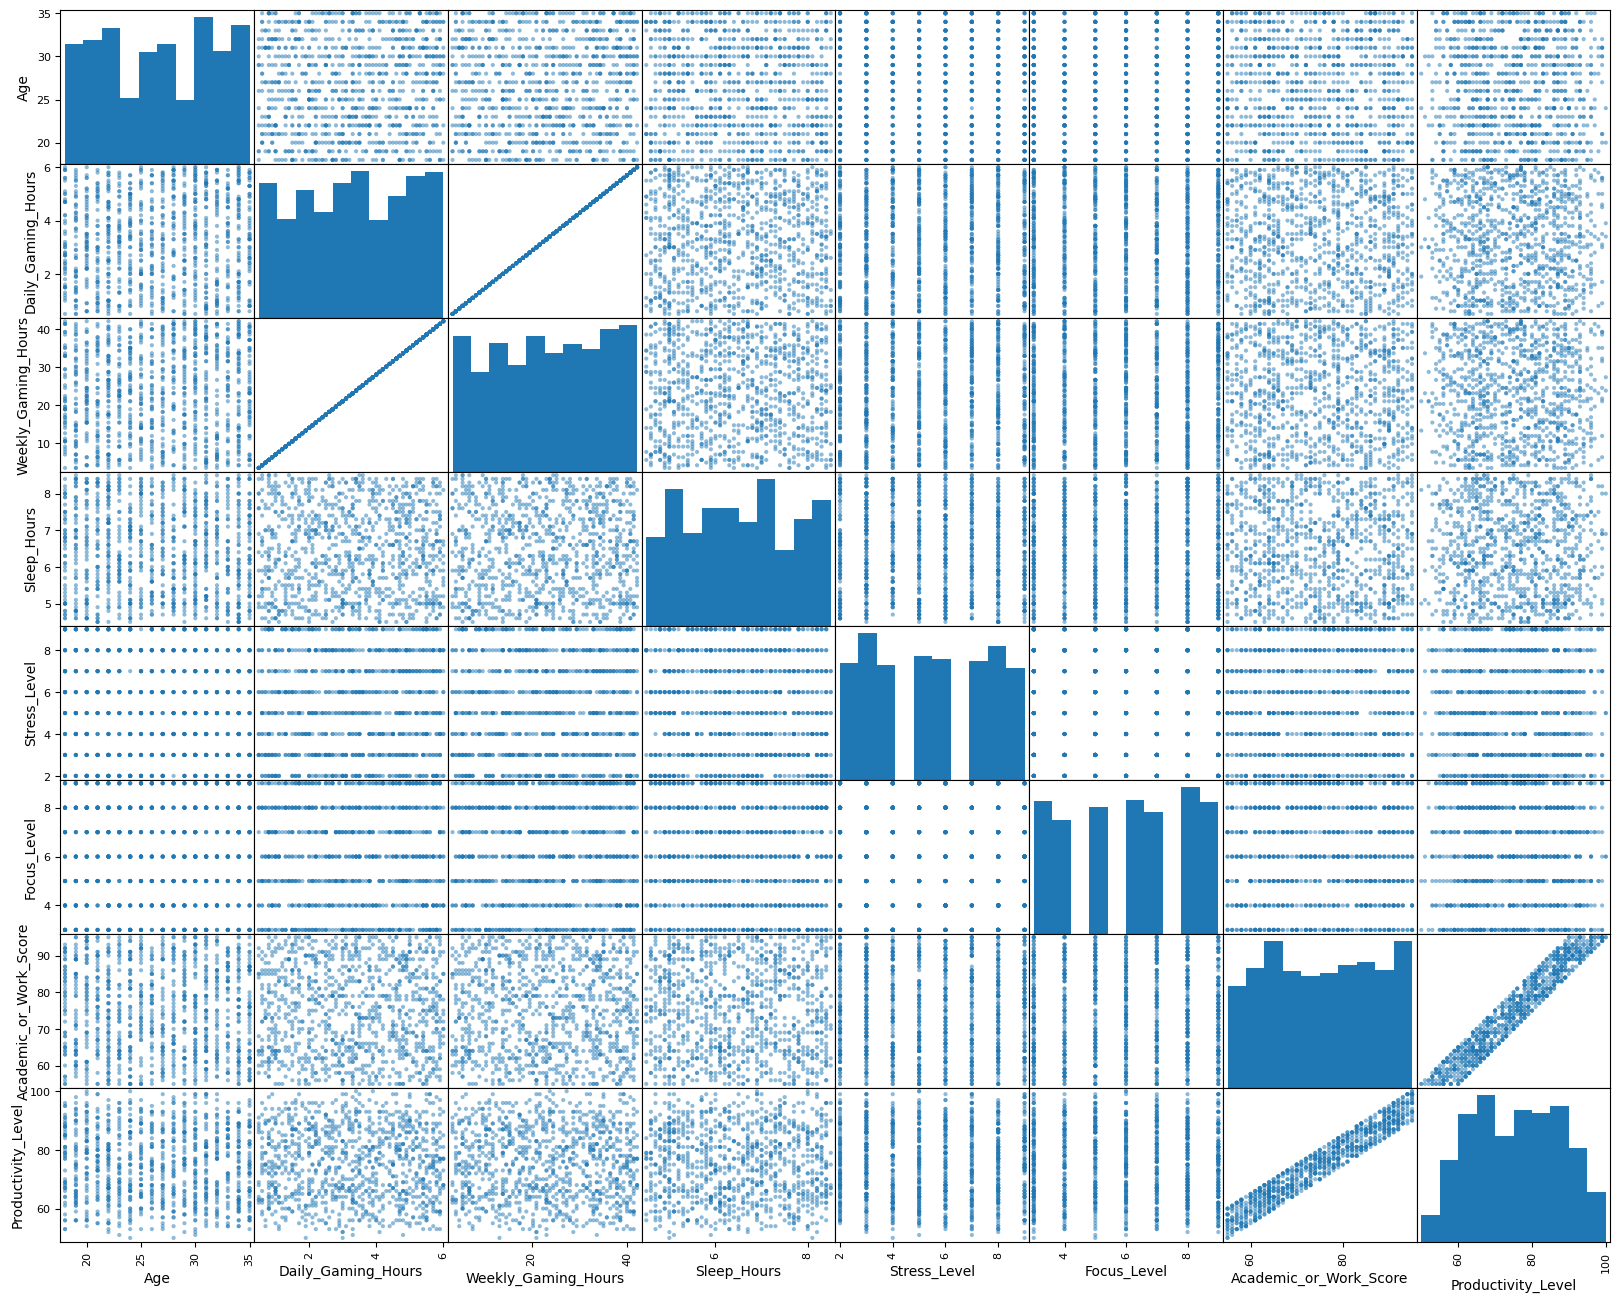

In [22]:
scatter_matrix(df[attributes], figsize=(20,16))